In [4]:
# azureml-core of version 1.0.72 or higher is required
# azureml-dataprep[pandas] of version 1.1.34 or higher is required
from azureml.core import Workspace, Dataset

subscription_id = '4b8d5c2c-bc89-48f4-ae09-c95b73e1aad6'
resource_group = 'rg-inft4104-winter26-60302136'
workspace_name = 'airquality'

workspace = Workspace(subscription_id, resource_group, workspace_name)

dataset = Dataset.get_by_name(workspace, name='airqualitydataset')

# Fix 1: Save the dataset to the variable 'df'
df = dataset.to_pandas_dataframe()

# Fix 2: Rename 'created_at' to 'Date', and 'field1' to 'AQI' 
# (Note: If your main MQ-135 reading is actually field2 or field5, change 'field1' below to match)
df.rename(columns={'created_at': 'Date', 'field2': 'AQI'}, inplace=True)

# Display the first few rows to confirm it worked
display(df.head())

{'infer_column_types': 'False', 'activity': 'to_pandas_dataframe'}
{'infer_column_types': 'False', 'activity': 'to_pandas_dataframe', 'activityApp': 'TabularDataset'}


,Date,entry_id,field1,AQI,field3,field4,field5,field6,field7,latitude,longitude,elevation,status
0,2024-04-06 06:30:27,1256,163,42.0,33.8,49.0,520.0,18.0,21.0,None,None,None,None
1,2024-04-06 06:31:30,1257,162,37.0,33.8,49.0,637.0,36.0,9.0,None,None,None,None
2,2024-04-06 06:32:32,1258,173,47.0,33.7,50.0,679.0,42.0,3.0,None,None,None,None
3,2024-04-06 06:33:34,1259,168,37.0,33.3,51.0,539.0,21.0,0.0,None,None,None,None
4,2024-04-06 06:34:36,1260,168,37.0,33.3,52.0,697.0,45.0,0.0,None,None,None,None


In [5]:
import pandas as pd
from statsmodels.tsa.arima.model import ARIMA
import warnings
warnings.filterwarnings("ignore") # Hides annoying red warning text

# Make sure the Date column is recognized as time and sorted
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)
df.sort_index(inplace=True)

# Train the ARIMA model to predict the air quality index
model = ARIMA(df['AQI'], order=(1, 1, 1))
model_fit = model.fit()

# Generate predictions for the dataset
df['AQI_Prediction'] = model_fit.predict()

# View a summary of how the model did
print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                    AQI   No. Observations:                 1333
Model:                 ARIMA(1, 1, 1)   Log Likelihood               -3216.491
Date:                Tue, 07 Apr 2026   AIC                           6438.982
Time:                        08:47:51   BIC                           6454.565
Sample:                             0   HQIC                          6444.822
                               - 1333                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0151      0.028     -0.542      0.588      -0.070       0.040
ma.L1         -0.9607      0.008   -117.908      0.000      -0.977      -0.945
sigma2         7.3136      0.267     27.344      0.0

In [6]:
# Calculate the error (difference between real AQI and predicted AQI)
df['Error'] = abs(df['AQI'] - df['AQI_Prediction'])

# Set a threshold for anomalies (e.g., the worst 5% of errors)
threshold = df['Error'].quantile(0.95)

# Flag anomalies: True if anomaly, False if normal
df['Is_Anomaly'] = df['Error'] > threshold

print("Anomalies found:")
display(df[df['Is_Anomaly'] == True])

Anomalies found:


,entry_id,field1,AQI,field3,field4,field5,field6,field7,latitude,longitude,elevation,status,AQI_Prediction,Error,Is_Anomaly
Date,,,,,,,,,,,,,,,
2024-04-06 06:30:27,1256,163,42.0,33.8,49.0,520.0,18.0,21.0,None,None,None,None,0.000000,42.000000,True
2024-04-06 06:32:32,1258,173,47.0,33.7,50.0,679.0,42.0,3.0,None,None,None,None,39.535732,7.464268,True
2024-04-06 06:52:03,1277,156,35.0,33.8,43.0,519.0,18.0,0.0,None,None,None,None,40.536902,5.536902,True
2024-04-06 06:53:05,1278,156,35.0,33.8,42.0,534.0,20.0,0.0,None,None,None,None,40.363242,5.363242,True
2024-04-06 07:05:23,1290,159,45.0,33.8,43.0,752.0,53.0,7.0,None,None,None,None,39.470811,5.529189,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-04-07 04:59:35,2507,215,48.0,32.8,55.0,675.0,41.0,1.0,None,None,None,None,41.010177,6.989823,True
2024-04-07 05:07:36,2514,214,47.0,32.8,55.0,665.0,40.0,3.0,None,None,None,None,41.304025,5.695975,True
2024-04-07 05:30:38,2535,207,48.0,32.8,53.0,659.0,39.0,0.0,None,None,None,None,41.635070,6.364930,True


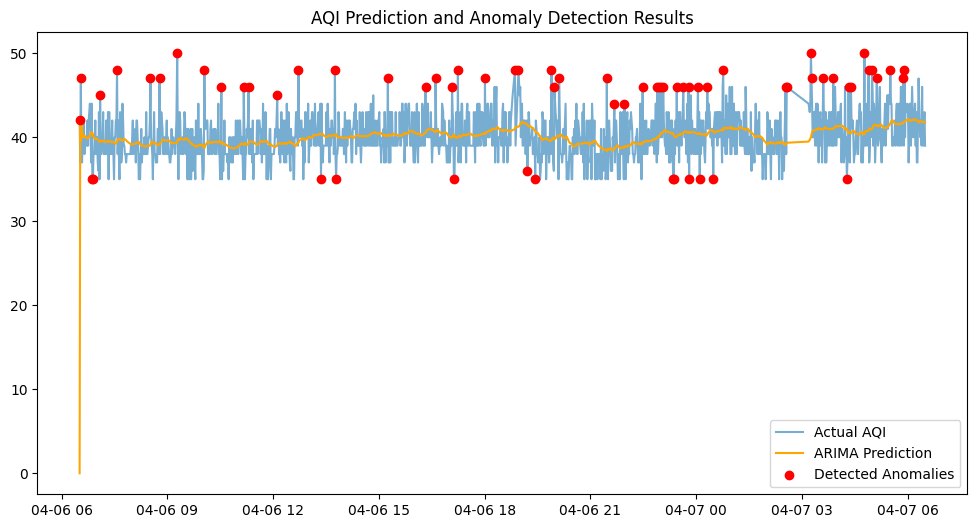

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

# Plot the standard results
plt.plot(df.index, df['AQI'], label='Actual AQI', alpha=0.6)
plt.plot(df.index, df['AQI_Prediction'], color='orange', label='ARIMA Prediction')

# Plot the results after anomaly detection
anomalies = df[df['Is_Anomaly']]
plt.scatter(anomalies.index, anomalies['AQI'], color='red', label='Detected Anomalies', zorder=5)

plt.legend()
plt.title('AQI Prediction and Anomaly Detection Results')
plt.show()

In [8]:
from azureml.core import Workspace, Model
import pickle

# 1. Save the trained model to a file
with open('arima_model.pkl', 'wb') as f:
    pickle.dump(model_fit, f)

# 2. Connect to your Azure workspace
ws = Workspace.from_config()

# 3. Register the model into the system
model = Model.register(workspace=ws, 
                       model_path="arima_model.pkl", 
                       model_name="aqi-arima-model-final")

print("Model registered successfully!")

Registering model aqi-arima-model-final
Model registered successfully!


In [10]:
from azureml.core import Workspace, Environment
from azureml.core.conda_dependencies import CondaDependencies

# 1. Connect to your workspace
subscription_id = '4b8d5c2c-bc89-48f4-ae09-c95b73e1aad6'
resource_group = 'rg-inft4104-winter26-60302136'
workspace_name = 'airquality'
ws = Workspace(subscription_id, resource_group, workspace_name)

# 2. Create a brand new environment from scratch
myenv = Environment(name="arima-stats-env")

# 3. Explicitly build the dependency list so it cannot be 'None'
conda_dep = CondaDependencies.create(
    pip_packages=[
        'azureml-defaults',
        'inference-schema[numpy-support]==1.3.0',
        'scikit-learn==1.0.2',
        'scipy==1.7.3',
        'statsmodels',
        'pandas'
    ]
)

# 4. Attach dependencies and register to Azure
myenv.python.conda_dependencies = conda_dep
myenv.register(workspace=ws)
print("Custom environment with statsmodels registered successfully!")

Custom environment with statsmodels registered successfully!
